$\bullet$ Example to illustrate how to use cocoa's new feature at [commit/89d9300](https://github.com/CosmoLike/cocoa/commit/89d9300178dd8f645cdc4b1dd3e9e0b55845e760)  
$\bullet$ Example to illustrate how to use cocoa_lsst_y1's new feature at [commit/1e7965b](https://github.com/CosmoLike/cocoa_lsst_y1/commit/1e7965bdce7ce568dcc8e6401c81bae201e0ba60)  

How the array should be passed to CoCoA?  
Example (your project may have more or less than 5 tomographic bins)  

[redshidt, bin 1, bin 2, bin 3, bin 4, bin 5] 

source_nz_local =  
[  
[z1 n1(z1) n2(z1) n3(z1) n4(z1) n5(z1)]  
[z2 n1(z2) n2(z2) n3(z2) n4(z2) n5(z2)]  
[z3 n1(z3) n2(z3) n3(z3) n4(z3) n5(z3)]  
...  
[zn n1(zn) n2(zn) n3(zn) n4(zn) n5(zn)]  
]  

Therefore, source_nz_local.shape = (len(z), Ntomo)

In [1]:
import numpy as np
import cosmolike_lsst_y1_interface as ci
# import euclidemu2
import getdist
import os
import camb
import scipy
import itertools
import iminuit
import functools
import matplotlib.pyplot as plt
import cocoa_photoz as cp

# 1- LSST Y1 redshift distribution. 
To begin, we demostrate the new functionality by passing the LSST Y1 n(z) as an array to the CosmoLike framework and compare the result with the old feature. Notice that "old" doesn't mean outdate. 

In [2]:
def lsst_y1_source_nz():
    path = "../../../external_modules/data/lsst_y1/lsst_y1_source.nz"
    nz_array = np.genfromtxt(path)
    # 1st return: to be used w/ the old feature, 
    # 2nd return: to be used w/ the new feature.
    return path, nz_array

type(nz): <class 'numpy.ndarray'>
∫ni(z)dz = 0.9999869996489905
∫ni(z)dz = 1.0000000000000002
∫ni(z)dz = 1.0
∫ni(z)dz = 0.9999999999999996
∫ni(z)dz = 0.9999504436048225


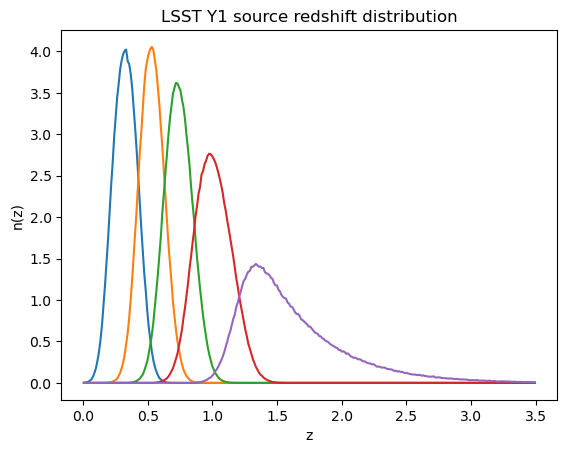

In [3]:
(_ , nz) = lsst_y1_source_nz()
print("type(nz):",type(nz)) # Cosmolike now supports n(z) as a Python array.
for i in range(1,nz.shape[1]):
    plt.plot(nz[:,0],nz[:,i])
    print("∫ni(z)dz =", np.trapz(y=nz[:,i],x=nz[:,0])) # Check that ni(z) are normalized.
plt.xlabel("z")    
plt.ylabel("n(z)")
plt.title("LSST Y1 source redshift distribution");


In [ ]:
(theta_of, xip_of, xim_of) = \
    cp.xi(external_nz_modeling=0,mod_nz=lsst_y1_source_nz) # old feature
(theta_nf, xip_nf, xim_nf) = \
    cp.xi(external_nz_modeling=1,mod_nz=lsst_y1_source_nz) # new feature

Old cosmolike feature: nz from file: ../../../external_modules/data/lsst_y1/lsst_y1_source.nz
New cosmolike feature: nz from array: source_nz_local


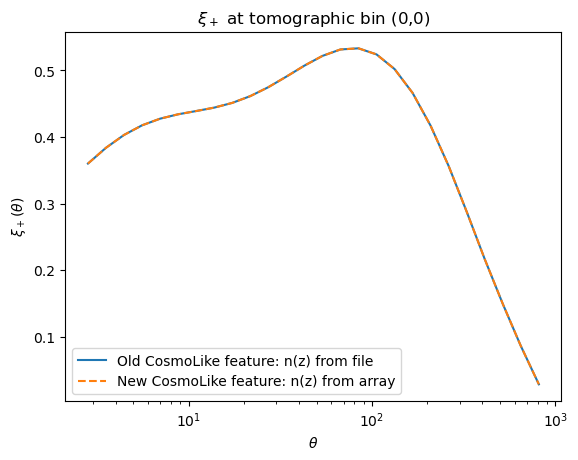

In [5]:
ti, tj = 0, 0 # tomo bin i, tomo bin j
plt.plot(theta_of, theta_of * xip_of[:,ti,tj] * 1e4,ls="-",label="Old CosmoLike feature: n(z) from file")
plt.plot(theta_nf, theta_nf * xip_nf[:,ti,tj] * 1e4,ls="--",label="New CosmoLike feature: n(z) from array")
plt.xscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi_+(\theta)$")
plt.legend(loc="best")
plt.title(r"$\xi_+$"+f" at tomographic bin ({ti},{tj})");

# 2 - Simple modification of the LSST Y1 n(z)
We test a simple and $\textit{unrealistic}$ modification of the LSST Y1 n(z) by adding uniform random contamination to each $n_i(z)$.

In [41]:
def uniform_random_contamination_nz():
    import random
    random.seed(42)
    path = "../../../external_modules/data/lsst_y1/lsst_y1_source"
    nz_array = np.genfromtxt(path+".nz")
    for col in range(1,nz_array.shape[1]): # Tomo bin: 1,2,3,4,5
        for row in range(nz_array.shape[0]): # Redshift index: 0,...,299
            c = random.uniform(0, 0.5)
            nz_array[:,col][row] += c # Add unrealist displacement.
        norm = np.trapz(y=nz_array[:,col],x=nz_array[:,0]) # Norm of ni(z)+c. 
        nz_array[:,col] /= norm # ni(z)+c normalized.
    np.savetxt(path+"_uniform_random_contamination_nz.nz",nz_array)
    return path+"_uniform_random_contamination_nz.nz",nz_array

type(nz): <class 'numpy.ndarray'>


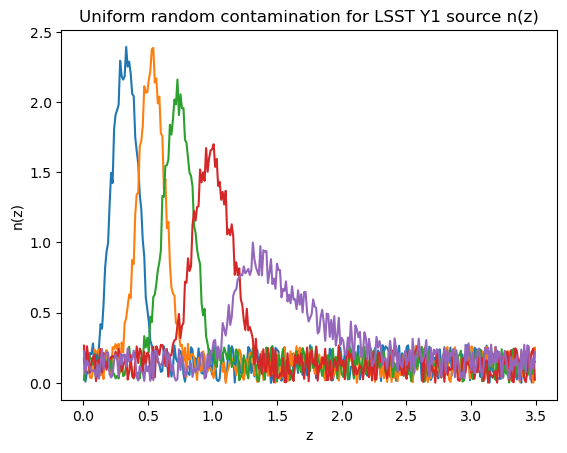

In [42]:
(_ , nz) = uniform_random_contamination_nz()
print("type(nz):",type(nz)) # Cosmolike now supports n(z) as a Python array.
for i in range(1,nz.shape[1]):
    plt.plot(nz[:,0],nz[:,i])
plt.xlabel("z")    
plt.ylabel("n(z)")
plt.title("Uniform random contamination for LSST Y1 source n(z)");


In [34]:
(theta_of, xip_of, xim_of) = \
    cp.xi(external_nz_modeling=0,mod_nz=uniform_random_contamination_nz) # old feature
(theta_nf, xip_nf, xim_nf) = \
    cp.xi(external_nz_modeling=1,mod_nz=uniform_random_contamination_nz) # new feature

Old cosmolike feature: nz from file: ../../../external_modules/data/lsst_y1/lsst_y1_source_uniform_random_contamination_nz.nz
New cosmolike feature: nz from array: source_nz_local


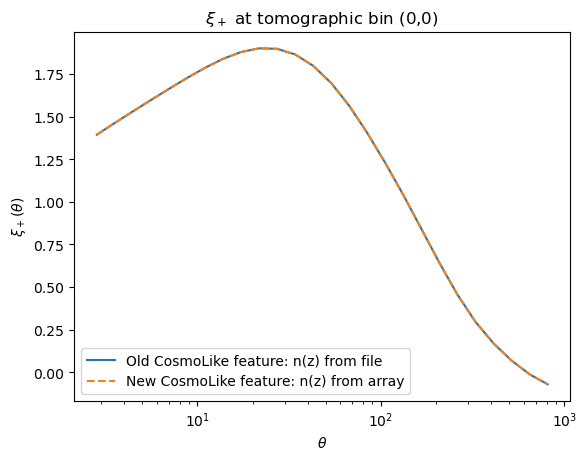

In [36]:
ti, tj = 0, 0 # tomo bin i, tomo bin j
plt.plot(theta_of, theta_of * xip_of[:,ti,tj] * 1e4,ls="-",label="Old CosmoLike feature: n(z) from file")
plt.plot(theta_nf, theta_nf * xip_nf[:,ti,tj] * 1e4,ls="--",label="New CosmoLike feature: n(z) from array")
plt.xscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi_+(\theta)$")
plt.legend(loc="best")
plt.title(r"$\xi_+$"+f" at tomographic bin ({ti},{tj})");

# 3 - LSST SRD redshift distribution
Now we test n(z) following the LSST Science Requirement Document (SRD)  
References:  
$\bullet$ [LSST_SRD_Redshift_Distributions_and_Binning](https://github.com/LSSTDESC/CCLX/blob/niko_nz_binning_update/LSST_SRD_Redshift_Distributions_and_Binning.ipynb)  
$\bullet$ [arxiv astro-ph: 0506614](https://arxiv.org/pdf/astro-ph/0506614)  
$\bullet$ Equation 5 in [LSST SRD](https://arxiv.org/pdf/1809.01669)

Main equations - see paper in the 2nd $\bullet$ above:  
$n(z)=d^2N/dzd\Omega = (z/z_0)^\beta\exp[-(z/z_0)^\alpha]$  
$p(z_\mathrm{ph}|z) = 1/(\sqrt{2\pi}\sigma_z)~\exp[-(z-z_\mathrm{ph}-z_\mathrm{bias})^2/(2\sigma_z^2)]$   
$n_i(z) = \int_{z_\mathrm{ph}^{i}}^{z_\mathrm{ph}^{i+1}}~dz_\mathrm{ph}~n(z)~p(z_\mathrm{ph}|z)$  
$n_i(z) = (1/2)~n(z)~[\mathrm{erf}(x_{i+1}) - \mathrm{erf}(x_{i})]$ where $x_i = (z_\mathrm{ph}^i - z + z_\mathrm{bias})/(\sqrt{2}\sigma_z)$  

In [4]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Addapted from the source code:
# https://github.com/LSSTDESC/CCLX/blob/niko_nz_binning_update/lsst_galaxy_sample.py
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt 
from scipy.special import erf
from scipy.integrate import simpson, cumulative_trapezoid

source_params_y1  = {"z_0": 0.13, "alpha": 0.78, "beta": 2.0,"sigma_z": 0.05,"n_tomo_bins": 5 ,"z_bias": 0.0 }
source_params_y4  = {"z_0": 0.12, "alpha": 0.75, "beta": 2.0,"sigma_z": 0.05,"n_tomo_bins": 5 ,"z_bias": 0.0 }
source_params_y7  = {"z_0": 0.12, "alpha": 0.71, "beta": 2.0,"sigma_z": 0.05,"n_tomo_bins": 5 ,"z_bias": 0.0 }
source_params_y10 = {"z_0": 0.11, "alpha": 0.68, "beta": 2.0,"sigma_z": 0.05,"n_tomo_bins": 5,"z_bias": 0.0 }

source_params = [source_params_y1,source_params_y4,source_params_y7,source_params_y10]

def dNdz(z,z0,alpha,beta):
    dNdz_values = np.array([(zz / z0)**beta * exp(-(zz / z0)**alpha) for zz in z])
    norm_factor = np.trapz(dNdz_values, x=z)
    return dNdz_values / norm_factor

def dNidz(i, z, sigma_z, z_bias, z0, alpha, beta, n_bins):
    # Compute photometric scatter as a function of redshift
    scatter = np.maximum(sigma_z * (1 + z), 1e-10)  # Avoid division by zero
    redshift_distribution = dNdz(z,z0,alpha,beta)
    
    cumulative_distribution = \
        cumulative_trapezoid(redshift_distribution, z, initial=0)
    total_galaxies = cumulative_distribution[-1]

    # Find the bin edges
    bin_edges = []
    fraction  = 0
    for _ in range(1, n_bins):
        fraction += total_galaxies/n_bins
        bin_edge  = np.interp(fraction, cumulative_distribution, z)
        bin_edges.append(bin_edge)
    bin_edges_ = [z[0]] + bin_edges + [z[-1]]

    # Compute integration limits
    upper_limit = (bin_edges_[i+1] - z + z_bias) / (np.sqrt(2) * scatter)
    lower_limit = (bin_edges_[i]   - z + z_bias) / (np.sqrt(2) * scatter)

    # Compute the photometric redshift distribution
    dNidz_values = 0.5 * redshift_distribution * (erf(upper_limit) - erf(lower_limit))
    norm_factor = np.trapz(dNidz_values, x=z)

    return dNidz_values / norm_factor

In [18]:
# ~~~~~~~~~~~~~~~~~~~~~~~~
# Define colors for plots: 
# https://github.com/LSSTDESC/CCLX/blob/niko_nz_binning_update/LSST_SRD_Redshift_Distributions_and_Binning.ipynb
# ~~~~~~~~~~~~~~~~~~~~~~~~

import cmasher as cmr
# Let us set up some plotting params here
plt.rcParams.update({
    "lines.linewidth": 3,
    "axes.labelsize": 25,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 15
})

n_bins=5

colors = {
    "sources": {
        "1": cmr.take_cmap_colors('cmr.ember',  n_bins,cmap_range=(0.2, 0.85), return_fmt='hex'),
        "10": cmr.take_cmap_colors('cmr.ember', n_bins,cmap_range=(0.2, 0.85), return_fmt='hex'),
        "4": cmr.take_cmap_colors('cmr.ember',  n_bins,cmap_range=(0.2, 0.85), return_fmt='hex'),
        "7": cmr.take_cmap_colors('cmr.ember',  n_bins,cmap_range=(0.2, 0.85), return_fmt='hex'),
    }
}

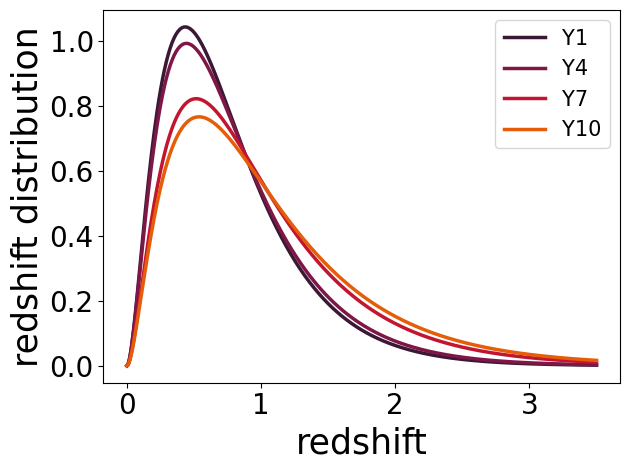

In [6]:
z = np.linspace(0.0, 3.5, 500)
years = [1,4,7,10]
cs = colors["sources"][f"{1}"]
for ii,sp in enumerate(source_params):
    z0      = sp["z_0"]
    alpha   = sp["alpha"]
    beta    = sp["beta"]
    sigma_z = sp["sigma_z"]
    z_bias  = sp["z_bias"]
    n_bins  = sp["n_tomo_bins"]
    plt.plot(z,dNdz(z,z0,alpha,beta),color=cs[ii],lw=2.5, label=f"Y{years[ii]}")
plt.legend(loc="best")
plt.xlabel("redshift")
plt.ylabel("redshift distribution")
plt.tight_layout();

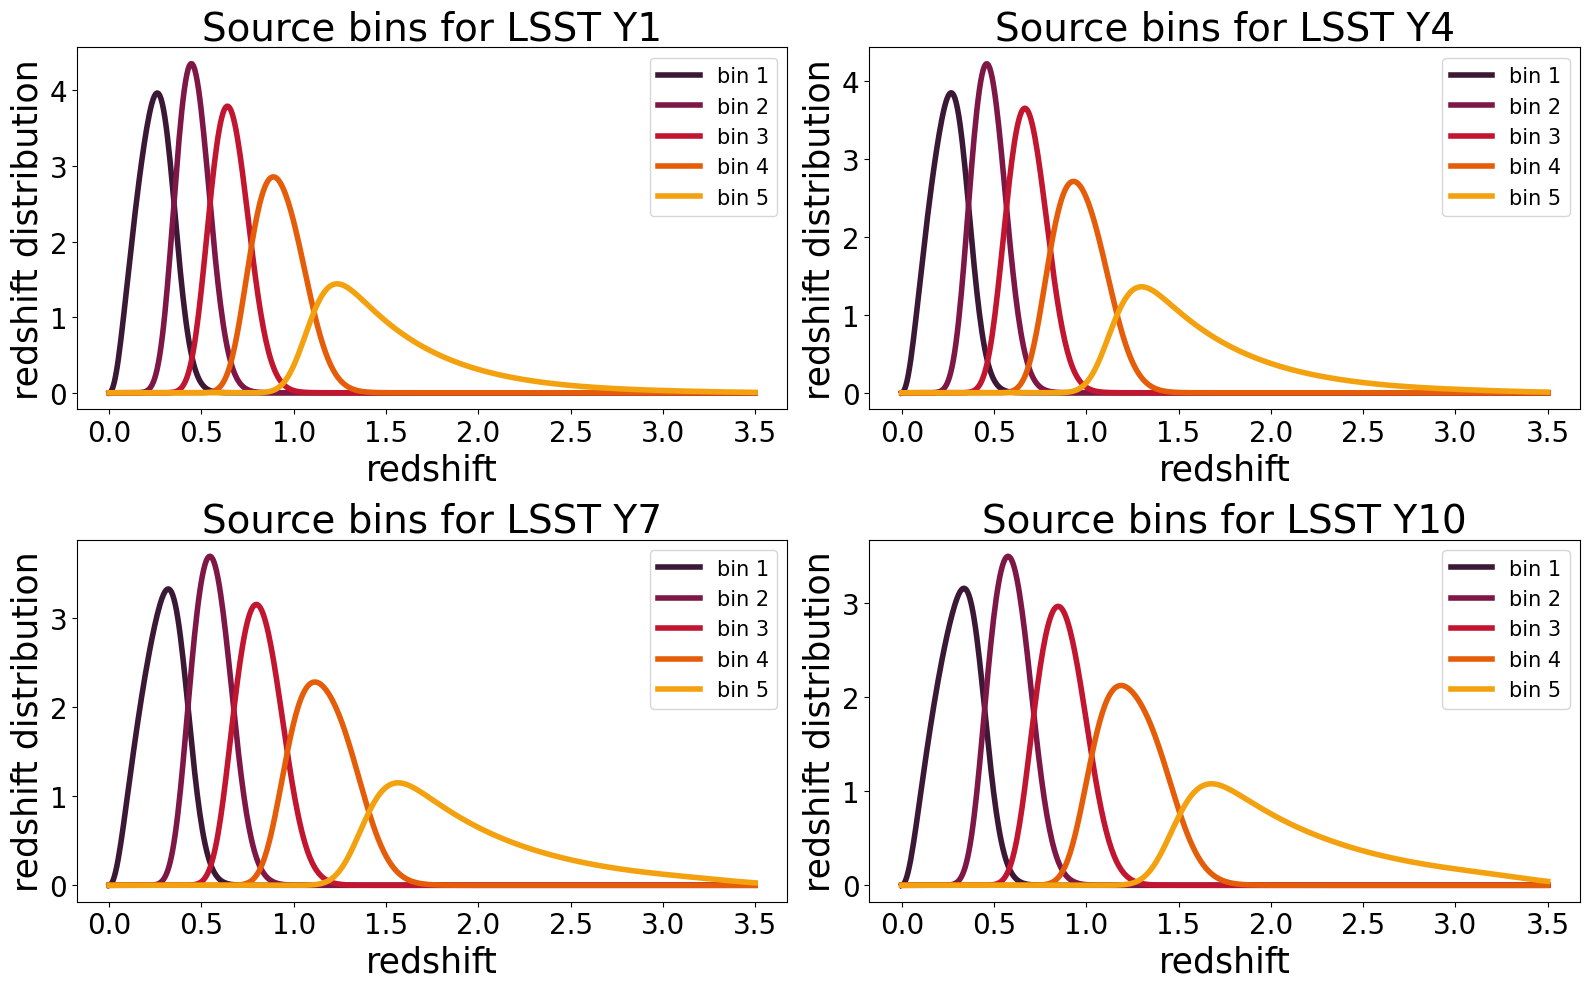

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for temp,(row,col) in enumerate([(0,0),(0,1),(1,0),(1,1)]):
    sp = source_params[temp]
    z0      = sp["z_0"]
    alpha   = sp["alpha"]
    beta    = sp["beta"]
    sigma_z = sp["sigma_z"]
    z_bias  = sp["z_bias"]
    n_bins  = sp["n_tomo_bins"]
    for i in range(n_bins):
        y = dNidz(i, z, sigma_z, z_bias, z0, alpha, beta, n_bins)
        axes[row,col].plot(z,y,color=cs[i],label=f"bin {i+1}",lw=4)
        axes[row,col].legend(loc="best")
        axes[row,col].set_xlabel("redshift")
        axes[row,col].set_ylabel("redshift distribution")
        axes[row,col].set_title(f"Source bins for LSST Y{years[temp]}")
plt.tight_layout()

In [8]:
idx_year = dict(list(enumerate([1, 4, 7, 10])))
year_idx = {v: k for k, v in idx_year.items()}

class nz_source_lsst_srd:
    def __init__(self, year):
        self.year = year
    def nz_source_lsst_srd_year(self):
        print("year:",self.year)
        sp = source_params[year_idx[self.year]]
        z0      = sp["z_0"]
        alpha   = sp["alpha"]
        beta    = sp["beta"]
        sigma_z = sp["sigma_z"]
        z_bias  = sp["z_bias"]
        n_bins  = sp["n_tomo_bins"]

        nz_list_unformated = \
            [z] + [dNidz(i, z, sigma_z, z_bias, z0, alpha, beta, n_bins) for i in range(n_bins)]
        nz_array_formated = \
            np.array(nz_list_unformated).T # Convert to CoCoA shape (len(z), Ntomo)
        # 1st return: none - in this example we don't use the old feature
        # 2nd return: to be used with the new feature 
        return None, nz_array_formated

In [9]:
xi_year = {}
for yr in [1,4,7,10]:
    nz_year = nz_source_lsst_srd(yr).nz_source_lsst_srd_year
    (theta_nf, xip_nf, xim_nf) = \
        cp.xi(external_nz_modeling=1,mod_nz=nz_year) # new feature
    xi_year.update({yr:(theta_nf, xip_nf, xim_nf)})

year: 1
New cosmolike feature: nz from array: source_nz_local
year: 4
New cosmolike feature: nz from array: source_nz_local
year: 7
New cosmolike feature: nz from array: source_nz_local
year: 10
New cosmolike feature: nz from array: source_nz_local


In [15]:
theta_yr1, xip_yr1, xim_yr1= xi_year[1]
theta_yr4, xip_yr4, xim_yr4= xi_year[4]
theta_yr7, xip_yr7, xim_yr7= xi_year[7]
theta_yr10, xip_yr10, xim_yr10= xi_year[10]

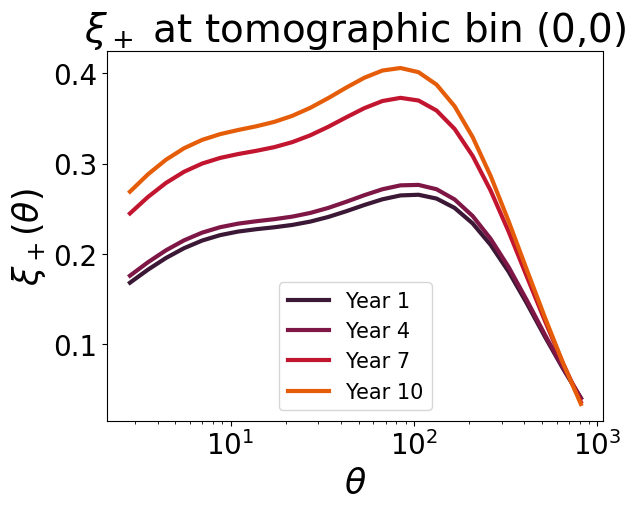

In [21]:
cs = colors["sources"][f"{1}"]
ti, tj = 0, 0 # tomo bin i, tomo bin j
for cs_idx, yr in enumerate([1,4,7,10]):
    theta_yr, xip_yr, xim_yr = xi_year[yr]
    plt.plot(theta_yr, theta_yr * xip_yr[:,ti,tj] * 1e4,c=cs[cs_idx],label=f"Year {yr}")
    plt.xscale("log")
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\xi_+(\theta)$")
    plt.legend(loc="best")
    plt.title(r"$\xi_+$"+f" at tomographic bin ({ti},{tj})");

# Photo-z models

In [55]:
from math import exp, sqrt 
from scipy.special import erf
from scipy.integrate import simpson, cumulative_trapezoid
alpha   = 2
beta    = 2

def edge():
    z = np.linspace(0.0, 3, 500)
    nvalues_ = np.array([zz ** alpha * exp(-zz ** beta) for zz in z])
    cumulative_distr = cumulative_trapezoid(nvalues_, z, initial=0)
    total_galaxies = cumulative_distr[-1]
    frac = total_galaxies / 2
    bin_edge_result = np.interp(frac, cumulative_distr, z)
    return bin_edge_result
print(edge())    

1.0873848224372493


In [56]:
from math import exp, sqrt 
from scipy.special import erf
from scipy.integrate import simpson, cumulative_trapezoid

z       = np.linspace(0.0, 3, 500)
alpha   = 2
beta    = 2
z_0     = 0.95 #edge()
z_bias  = 0

def n(z):
    n_val  = np.array([(zz / z_0)**alpha * exp(-(zz / z_0)**beta) for zz in z])
    nA     = np.trapz(n_val, x=z)
    return n_val / nA

zph_list = list(np.arange(0,3,0.6))
zph_list.append(3)
zph = np.array(zph_list)

def ni(z,i,model):
    if (model==1):
        scatter = 0.05 * (1 + z)
        x_upper = (zph[i+1] - z + z_bias) / (np.sqrt(2) * scatter)
        x_lower = (zph[i]   - z + z_bias) / (np.sqrt(2) * scatter)
        ni_val = 0.5 * n(z) * (erf(x_upper) - erf(x_lower))
        niA    = np.trapz(ni_val, x=z)
    elif (model == 2):
        scatter = np.where(z<1,0.2,0.5)
        x_upper = (zph[i+1] - z + z_bias) / (np.sqrt(2) * scatter)
        x_lower = (zph[i]   - z + z_bias) / (np.sqrt(2) * scatter)
        ni_val = 0.5 * n(z) * (erf(x_upper) - erf(x_lower))
        niA    = np.trapz(ni_val, x=z)
    return ni_val # / niA
    

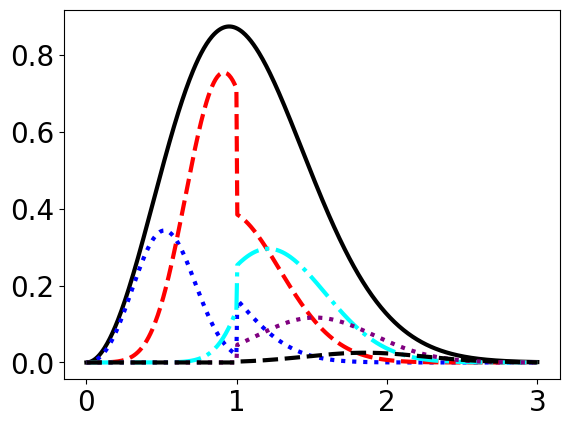

In [57]:
plt.plot(z,n(z),"k")
plt.plot(z,ni(z,0,model=2),ls=":",c="b")
plt.plot(z,ni(z,1,model=2),ls="--",c="r")
plt.plot(z,ni(z,2,model=2),ls="-.",c="cyan")
plt.plot(z,ni(z,3,model=2),ls=":",c="purple")
plt.plot(z,ni(z,4,model=2),ls="--",c="k")

# Outliers

# PCA